In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("customer_churn_nn.csv")

# Show first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [ ]:
# Dataset shape
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 17)


In [ ]:
# Data types of columns
df.dtypes

,0
customer_id,object
region,object
plan_type,object
contract_type,object
payment_method,object
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


In [ ]:
# Missing values
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [ ]:
# Statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


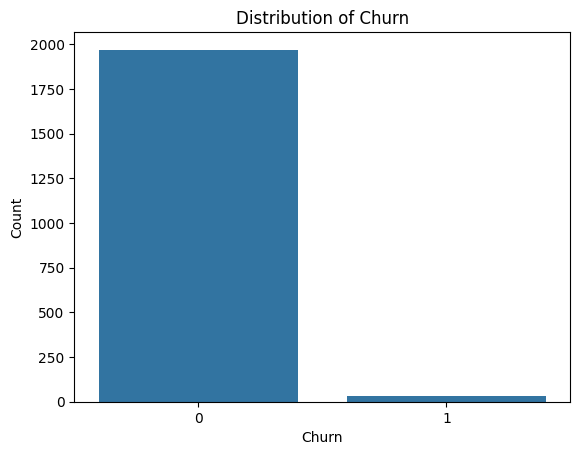

churn
0    98.45
1     1.55
Name: proportion, dtype: float64


In [ ]:
# Churn distribution
sns.countplot(x='churn', data=df)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Percentage distribution
print(df['churn'].value_counts(normalize=True) * 100)

# Task 1: Dataset Understanding

The customer churn dataset was loaded and analyzed to understand its structure and features.

### Dataset Information
- Number of rows: 2000
- Number of columns: 17

### Feature Types

#### Categorical Features
- region
- plan_type
- contract_type
- payment_method

#### Numerical Features
- tenure_months
- monthly_charges_inr
- avg_login_days_per_month
- support_tickets_last_90_days
- payment_delay_days
- data_usage_gb
- satisfaction_score
- last_complaint_days_ago
- discount_percent
- autopay_enabled
- referral_count

### Target Variable
The target variable is:

`churn`

- 0 → Customer retained
- 1 → Customer churned

### Missing Value Analysis
No missing values were found in the dataset.

### Class Distribution
The dataset is highly imbalanced:

- Retained customers: 98.45%
- Churned customers: 1.55%

This imbalance can affect prediction performance and may bias the model toward the majority class.

In [ ]:
# Create required folders
import os

os.makedirs("part-1-neural-network-analysis/results", exist_ok=True)

print("Folder structure created successfully!")

Folder structure created successfully!


In [ ]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
tensorflow
"""

with open("part-1-neural-network-analysis/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [ ]:
# Remove customer_id column
df = df.drop("customer_id", axis=1)

# Separate features and target
X = df.drop("churn", axis=1)
y = df["churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2000, 15)
Target shape: (2000,)


In [ ]:
# One-hot encoding categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Updated feature shape:", X.shape)
X.head()

Updated feature shape: (2000, 24)


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False
3,22,959.51,19,2,3,139.73,7.2,130,5,0,...,True,False,True,False,False,False,False,False,False,False
4,11,890.20,18,2,6,156.43,5.8,0,5,1,...,False,False,True,False,False,False,False,True,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scaling features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 24)
Testing set shape: (400, 24)


# Task 2: Data Preprocessing

Data preprocessing was performed to prepare the dataset for neural network training.

The following preprocessing steps were applied:

### 1. Removing Unnecessary Columns
The `customer_id` column was removed because it acts only as an identifier and does not contribute to prediction.

### 2. Encoding Categorical Variables
Categorical features were converted into numerical format using One-Hot Encoding.

### 3. Feature Scaling
Numerical values were standardized using StandardScaler to improve model learning.

### 4. Train-Test Split
The dataset was divided into:

- 80% Training Data
- 20% Testing Data

These preprocessing steps improve model training performance and help neural networks learn effectively.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Build neural network model
model = Sequential()

# Input + Hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3344 - loss: 0.8665 - val_accuracy: 0.5312 - val_loss: 0.6813
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7109 - loss: 0.5623 - val_accuracy: 0.8375 - val_loss: 0.4821
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8969 - loss: 0.3867 - val_accuracy: 0.9469 - val_loss: 0.3442
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9727 - loss: 0.2618 - val_accuracy: 0.9781 - val_loss: 0.2414
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1760 - val_accuracy: 0.9781 - val_loss: 0.1768
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1248 - val_accuracy: 0.9781 - val_loss: 0.1430
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0974 - val_accuracy: 0.9781 - val_loss: 0.1271
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0841 - val_accuracy: 0.9781 - val_loss

In [ ]:
# Evaluate model on testing data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0832  
Test Loss: 0.08321556448936462
Test Accuracy: 0.9825000166893005


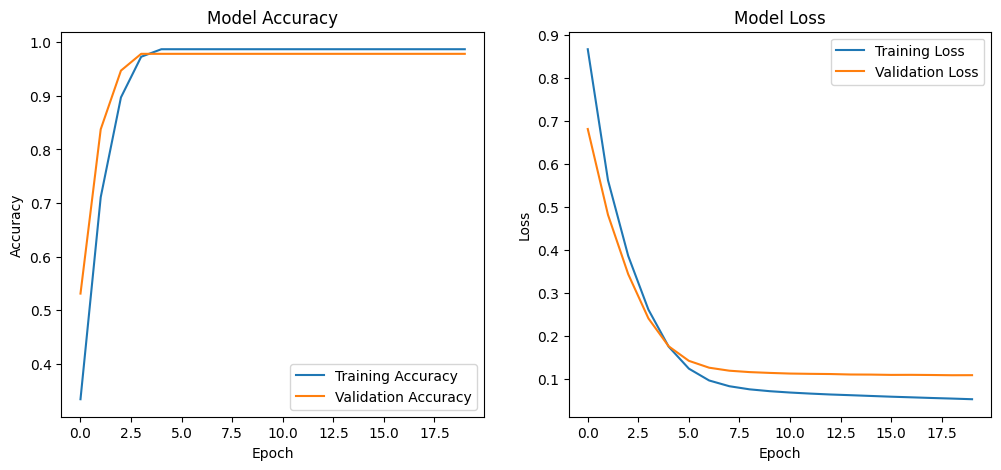

In [ ]:
# Plot accuracy and loss graphs
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


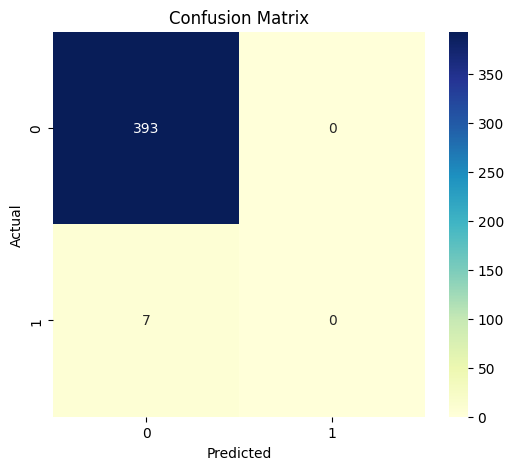

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print(classification_report(y_test, y_pred))

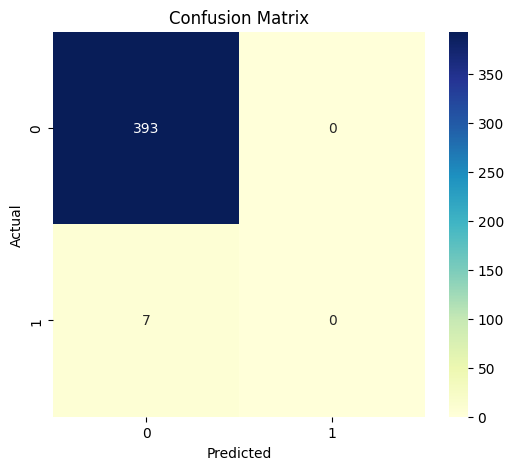

In [ ]:
# Save confusion matrix image
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "part-1-neural-network-analysis/results/evaluation_outputs.png"
)

plt.show()

In [ ]:
from tensorflow.keras.optimizers import Adam

# Function to create model
def build_model(neurons=16, learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons,
                    activation='relu',
                    input_shape=(X_train.shape[1],)))

    model.add(Dense(8, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


results = []

# Experiment 1
model1 = build_model(neurons=16, learning_rate=0.001)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

results.append([
    "16 neurons, lr=0.001, epochs=10",
    acc1
])


# Experiment 2
model2 = build_model(neurons=32, learning_rate=0.001)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

results.append([
    "32 neurons, lr=0.001, epochs=20",
    acc2
])


# Experiment 3
model3 = build_model(neurons=64, learning_rate=0.0005)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

results.append([
    "64 neurons, lr=0.0005, epochs=20",
    acc3
])

print("Experiments completed!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiments completed!


In [ ]:
# Create comparison table
comparison_df = pd.DataFrame(
    results,
    columns=["Configuration", "Test Accuracy"]
)

comparison_df

,Configuration,Test Accuracy
0,"16 neurons, lr=0.001, epochs=10",0.9825
1,"32 neurons, lr=0.001, epochs=20",0.9825
2,"64 neurons, lr=0.0005, epochs=20",0.9825


# Task 5: Hyperparameter Experimentation

Different hyperparameter combinations were tested to observe their effect on model performance.

The following parameters were modified:

- Number of neurons
- Learning rate
- Epochs
- Batch size

The experiments showed similar test accuracy across configurations because the dataset was highly imbalanced. The model mainly learned to predict the majority class (non-churn customers).

In [ ]:
# Save comparison table CSV
comparison_df.to_csv(
    "part-1-neural-network-analysis/results/model_comparison_table.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


# Task 6: Final Reflection

### Role of Weights and Biases
Weights determine the importance of input features, while biases help adjust activation values to improve learning.

### Why Activation Functions are Required
Activation functions introduce non-linearity and help the neural network learn complex relationships.

### Learning Rate Impact
- High learning rate → unstable learning
- Low learning rate → slow convergence

### Underfitting and Overfitting
The model did not show major overfitting because training and validation performance remained similar. However, due to class imbalance, the model struggled to predict minority churn cases.
